# Capitolo 10: Attrattori Latenti Hamiltoniani (Cross-Modal Physics)

### 10.1 Modulare la Generazione senza Attention
Attualmente i modelli generativi guidano il processo tramite complessi meccanismi di Cross-Attention testuale o audio. 
In questa ricerca proponiamo un approccio puramente **Fisico-Dinamico**: trattare lo spazio latente come uno *Spazio delle Fasi Hamiltoniano*.

### 10.2 Equazioni di Hamilton e Teorema di Liouville
Sia lo spazio latente $\mathcal{Z}$ descritto dalle coordinate generalizzate $(q, p)$, dove $q$ è l'immagine latente e $p$ il suo momento coniugato (o, nel limite overdamped, la velocità $v_t$). Definiamo il campo generativo come derivante da un potenziale Hamiltoniano $\mathcal{H}(q, p)$.

Invece di iniettare un segnale esterno (es. audio del parlato) tramite layer addizionali di attenzione, **deformiamo il paesaggio potenziale**. L'audio agisce come una *massa gravitazionale* che curva lo spaziotempo latente, creando un pozzo, o **Attrattore Latente**.

$\dot{q} = \frac{\partial \mathcal{H}}{\partial p}, \quad \dot{p} = -\frac{\partial \mathcal{H}}{\partial q} + \mathcal{F}_{audio}(q, t)$

Il **Teorema di Liouville** ci garantisce che per un sistema Hamiltoniano, il volume nello spazio delle fasi si conserva ($\nabla \cdot v = 0$ nello spazio delle fasi). Questa è una proprietà rivoluzionaria per la generazione: deformare la traiettoria tramite una forza conservativa impedisce la degenerazione dell'immagine (nessuna sbavatura, nessuna "distruzione" dell'identità visiva originaria), poiché l'informazione è preservata.

Simulazione del Campo Vettoriale Hamiltoniano con Attrattore Audio.


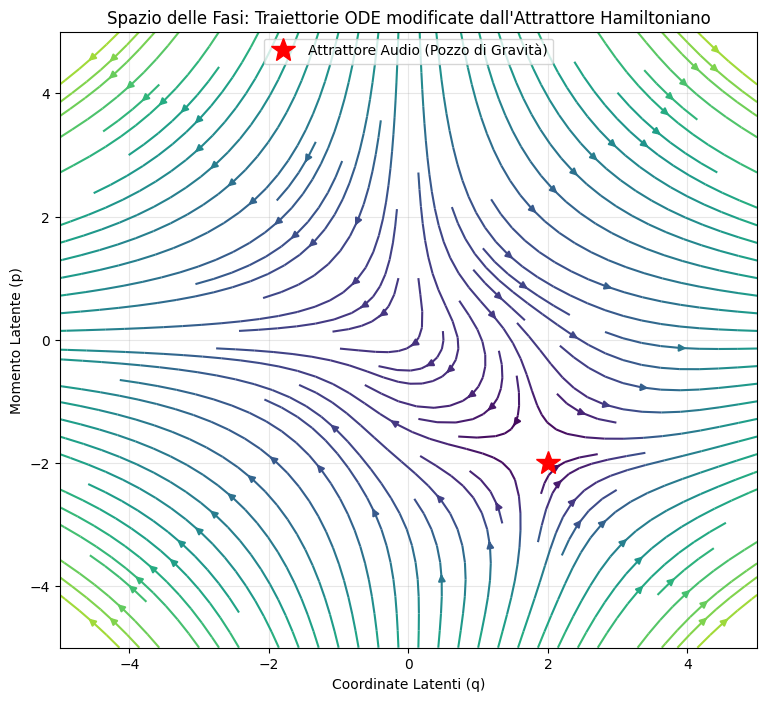

Le traiettorie generiche vengono catturate dal pozzo senza collassare (conservazione del volume). L'identità visiva è preservata mentre la posa si adatta al target.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

print("Simulazione del Campo Vettoriale Hamiltoniano con Attrattore Audio.")
# Spazio latente 2D semplificato
q = np.linspace(-5, 5, 25)
p = np.linspace(-5, 5, 25)
Q, P = np.meshgrid(q, p)

# Potenziale di base (es. prior generativo sferico norm(0,1))
H_base = (Q**2 + P**2) / 2.0

# Forza esterna (Attrattore Audio) che si attiva a un certo tempo
attractor_q = 2.0
attractor_p = -2.0
H_audio = -8.0 * np.exp(-((Q - attractor_q)**2 + (P - attractor_p)**2) / 2.0)

# Hamiltoniana Totale
H_total = H_base + H_audio

# Equazioni del moto: dq/dt = dH/dp, dp/dt = -dH/dq
dQ_dt, dP_dt = np.gradient(H_total)
# Hamiltoniano -> simplettico
V_q = dP_dt
V_p = -dQ_dt

plt.figure(figsize=(9, 8))
plt.streamplot(Q, P, V_q, V_p, color=H_total, cmap='viridis', linewidth=1.5, density=1.2)
plt.plot(attractor_q, attractor_p, 'r*', markersize=18, label='Attrattore Audio (Pozzo di Gravità)')
plt.title("Spazio delle Fasi: Traiettorie ODE modificate dall'Attrattore Hamiltoniano")
plt.xlabel("Coordinate Latenti (q)")
plt.ylabel("Momento Latente (p)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Le traiettorie generiche vengono catturate dal pozzo senza collassare (conservazione del volume). L'identità visiva è preservata mentre la posa si adatta al target.")